# MNIST Handwritten Digit Classification with myNN

This notebook demonstrates training a neural network on the MNIST dataset using our custom myNN framework.

## Setup and Imports

In [1]:
import sys
import os

# Add parent directory to path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

print(f"Added '{parent_dir}' to sys.path")

Added 'c:\Users\ahris\Coding\zero_to_cnn' to sys.path


In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from myNN import nn, AF, LF, optim

# For downloading MNIST
from tensorflow.keras.datasets import mnist

print("All imports successful!")

All imports successful!


## Load and Preprocess MNIST Dataset

In [3]:
# Download MNIST dataset
print("Downloading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"\nOriginal shapes:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")


Original shapes:
X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


In [4]:
# Preprocess the data
# 1. Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 2. Flatten 28x28 images to 784-dimensional vectors
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

print(f"\nPreprocessed shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

print(f"\nData statistics:")
print(f"X_train min: {X_train.min():.3f}, max: {X_train.max():.3f}")
print(f"Label range: {y_train.min()} to {y_train.max()}")


Preprocessed shapes:
X_train: (60000, 784)
X_test: (10000, 784)

Data statistics:
X_train min: 0.000, max: 1.000
Label range: 0 to 9


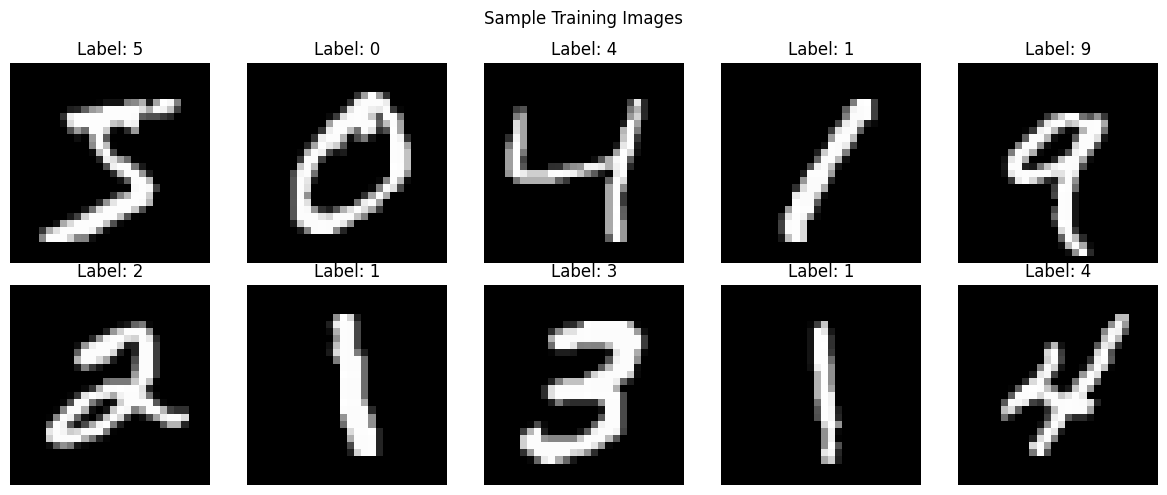

In [5]:
# Visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    # Reshape back to 28x28 for visualization
    img = X_train[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.suptitle('Sample Training Images')
plt.tight_layout()
plt.show()

## Build Neural Network Model

Architecture:
- Input: 784 (28x28 flattened)
- Hidden Layer 1: 128 neurons + ReLU
- Hidden Layer 2: 64 neurons + ReLU
- Output: 10 classes (digits 0-9)

In [6]:
# Create layers
layer1 = nn.Linear(784, 128)
relu1 = AF.ReLU()

layer2 = nn.Linear(128, 64)
relu2 = AF.ReLU()

layer3 = nn.Linear(64, 10)

# Loss function and optimizer
loss_fn = LF.CrossEntropyLoss()
optimizer = optim.SGD([layer1, layer2, layer3], lr=0.01)

print("Model architecture:")
print(f"Layer 1: {layer1.weights.shape} (784 -> 128)")
print(f"Layer 2: {layer2.weights.shape} (128 -> 64)")
print(f"Layer 3: {layer3.weights.shape} (64 -> 10)")
print(f"\nTotal parameters: {784*128 + 128 + 128*64 + 64 + 64*10 + 10}")

Model architecture:
Layer 1: (784, 128) (784 -> 128)
Layer 2: (128, 64) (128 -> 64)
Layer 3: (64, 10) (64 -> 10)

Total parameters: 109386


## Helper Functions

In [7]:
def forward_pass(X):
    """Forward pass through the network"""
    h1 = layer1(X)
    h1_act = relu1(h1)
    h2 = layer2(h1_act)
    h2_act = relu2(h2)
    output = layer3(h2_act)
    return output

def backward_pass(grad):
    """Backward pass through the network"""
    grad = layer3.backward(grad)
    grad = relu2.backward(grad)
    grad = layer2.backward(grad)
    grad = relu1.backward(grad)
    grad = layer1.backward(grad)
    return grad

def compute_accuracy(X, y):
    """Compute classification accuracy"""
    output = forward_pass(X)
    predictions = np.argmax(output, axis=1)
    accuracy = np.mean(predictions == y)
    return accuracy

def create_batches(X, y, batch_size):
    """Create mini-batches from data"""
    n_samples = X.shape[0]
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    batches = []
    for start_idx in range(0, n_samples, batch_size):
        end_idx = min(start_idx + batch_size, n_samples)
        batch_indices = indices[start_idx:end_idx]
        batches.append((X[batch_indices], y[batch_indices]))
    
    return batches

print("Helper functions defined!")

Helper functions defined!


## Training Loop

In [8]:
# Training hyperparameters
num_epochs = 30
batch_size = 32

# Track metrics
train_losses = []
train_accuracies = []
test_accuracies = []

print("Starting training...\n")
print(f"Epochs: {num_epochs}")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {optimizer.lr}")
print("="*60)

for epoch in range(num_epochs):
    # Create batches for this epoch
    batches = create_batches(X_train, y_train, batch_size)
    
    epoch_losses = []
    
    # Train on each batch
    for batch_idx, (batch_X, batch_y) in enumerate(batches):
        # Forward pass
        output = forward_pass(batch_X)
        
        # Compute loss
        loss = loss_fn.calculate(output, batch_y)
        epoch_losses.append(loss)
        
        # Compute gradient (softmax + cross entropy)
        batch_size_current = batch_X.shape[0]
        num_classes = 10
        one_hot = np.zeros((batch_size_current, num_classes))
        one_hot[np.arange(batch_size_current), batch_y] = 1
        grad = (output - one_hot) / batch_size_current
        
        # Backward pass
        backward_pass(grad)
        
        # Update weights
        optimizer.step()
        optimizer.zero_grad()
    
    # Compute epoch metrics
    avg_loss = np.mean(epoch_losses)
    train_acc = compute_accuracy(X_train[:1000], y_train[:1000])  # Sample for speed
    test_acc = compute_accuracy(X_test, y_test)
    
    train_losses.append(avg_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Loss: {avg_loss:.4f} | "
          f"Train Acc: {train_acc*100:.2f}% | "
          f"Test Acc: {test_acc*100:.2f}%")

print("\n" + "="*60)
print(f"✓ Training completed!")
print(f"Final Test Accuracy: {test_accuracies[-1]*100:.2f}%")

Starting training...

Epochs: 30
Batch size: 32
Learning rate: 0.01
Epoch 1/30 | Loss: 1.8338 | Train Acc: 89.30% | Test Acc: 89.36%
Epoch 2/30 | Loss: 1.6934 | Train Acc: 91.70% | Test Acc: 92.00%
Epoch 3/30 | Loss: 1.6560 | Train Acc: 93.10% | Test Acc: 93.13%
Epoch 4/30 | Loss: 1.6342 | Train Acc: 93.90% | Test Acc: 93.82%
Epoch 5/30 | Loss: 1.6194 | Train Acc: 94.30% | Test Acc: 94.28%
Epoch 6/30 | Loss: 1.6084 | Train Acc: 94.30% | Test Acc: 94.53%
Epoch 7/30 | Loss: 1.5994 | Train Acc: 94.60% | Test Acc: 94.78%
Epoch 8/30 | Loss: 1.5920 | Train Acc: 95.00% | Test Acc: 95.06%
Epoch 9/30 | Loss: 1.5858 | Train Acc: 95.10% | Test Acc: 95.27%
Epoch 10/30 | Loss: 1.5804 | Train Acc: 95.20% | Test Acc: 95.43%
Epoch 11/30 | Loss: 1.5758 | Train Acc: 95.20% | Test Acc: 95.50%
Epoch 12/30 | Loss: 1.5714 | Train Acc: 95.30% | Test Acc: 95.64%
Epoch 13/30 | Loss: 1.5677 | Train Acc: 95.70% | Test Acc: 95.76%
Epoch 14/30 | Loss: 1.5641 | Train Acc: 95.80% | Test Acc: 95.92%
Epoch 15/30 | Los

## Visualize Training Progress

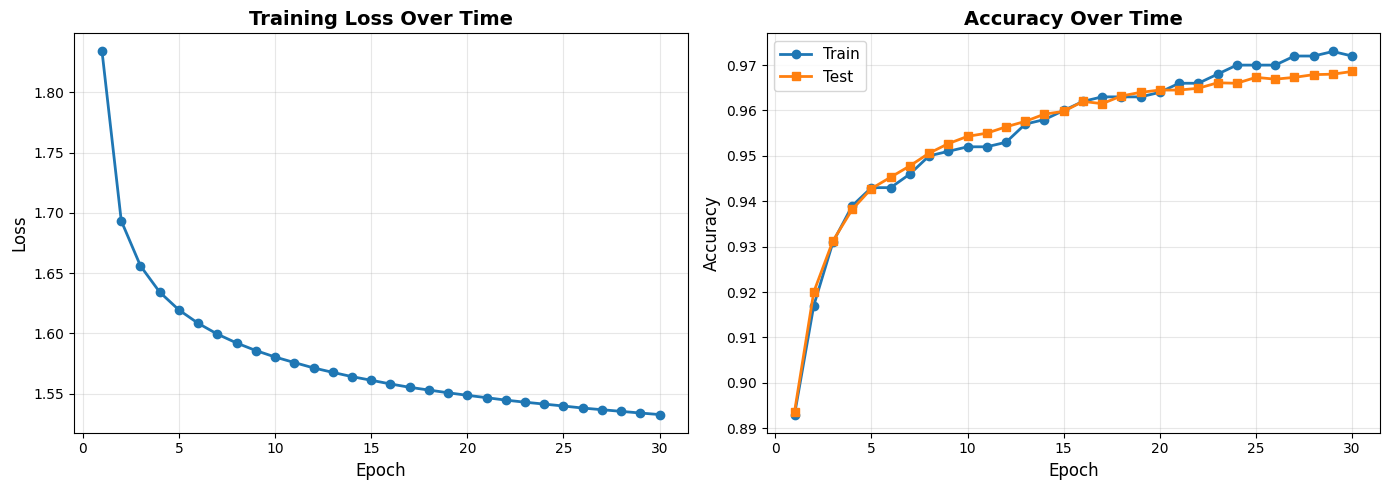

In [9]:
# Plot training metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(range(1, num_epochs+1), train_losses, marker='o', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(range(1, num_epochs+1), train_accuracies, marker='o', linewidth=2, label='Train')
axes[1].plot(range(1, num_epochs+1), test_accuracies, marker='s', linewidth=2, label='Test')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy Over Time', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluate on Test Set

In [10]:
# Get predictions on test set
test_output = forward_pass(X_test)
test_predictions = np.argmax(test_output, axis=1)

# Compute overall accuracy
test_accuracy = np.mean(test_predictions == y_test)

print(f"Test Set Performance:")
print(f"  Total samples: {len(y_test)}")
print(f"  Correct predictions: {np.sum(test_predictions == y_test)}")
print(f"  Accuracy: {test_accuracy*100:.2f}%")

# Per-class accuracy
print(f"\nPer-class accuracy:")
for digit in range(10):
    mask = y_test == digit
    digit_acc = np.mean(test_predictions[mask] == y_test[mask])
    print(f"  Digit {digit}: {digit_acc*100:.2f}%")

Test Set Performance:
  Total samples: 10000
  Correct predictions: 9686
  Accuracy: 96.86%

Per-class accuracy:
  Digit 0: 98.78%
  Digit 1: 98.68%
  Digit 2: 97.19%
  Digit 3: 96.83%
  Digit 4: 96.74%
  Digit 5: 95.40%
  Digit 6: 96.97%
  Digit 7: 95.33%
  Digit 8: 97.23%
  Digit 9: 95.14%


## Visualize Predictions

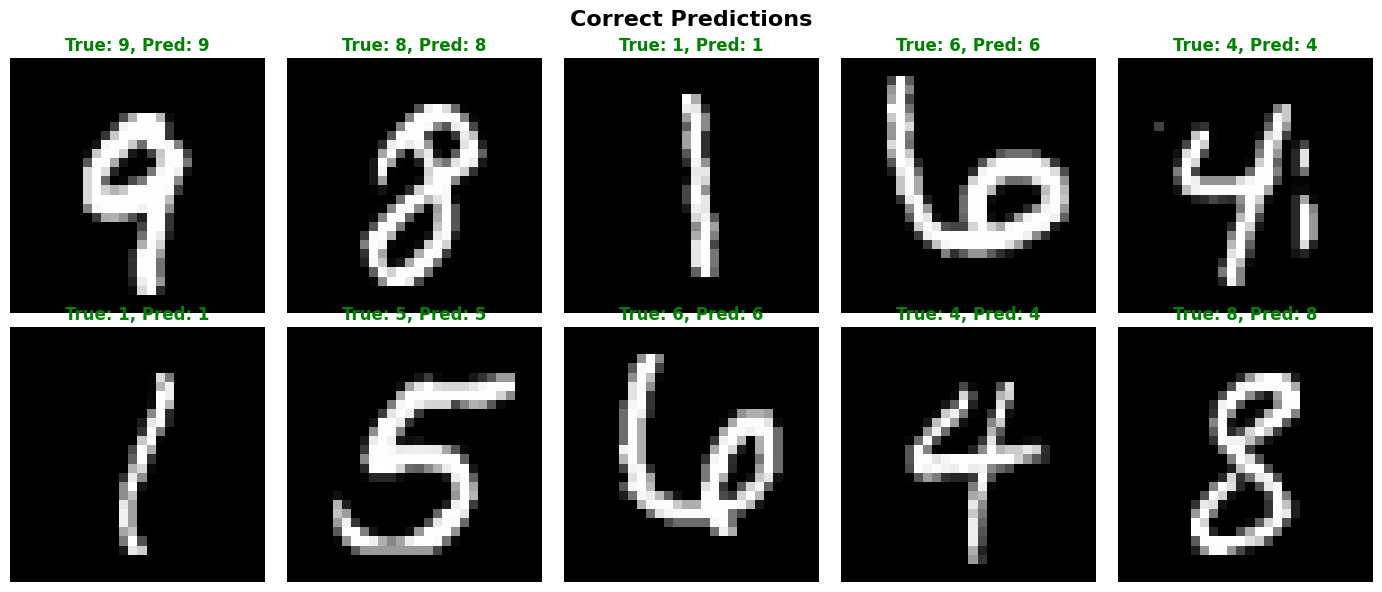

In [11]:
# Show some correct predictions
correct_mask = test_predictions == y_test
correct_indices = np.where(correct_mask)[0]
sample_correct = np.random.choice(correct_indices, size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    idx = sample_correct[i]
    img = X_test[idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"True: {y_test[idx]}, Pred: {test_predictions[idx]}", 
                 color='green', fontweight='bold')
    ax.axis('off')
plt.suptitle('Correct Predictions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

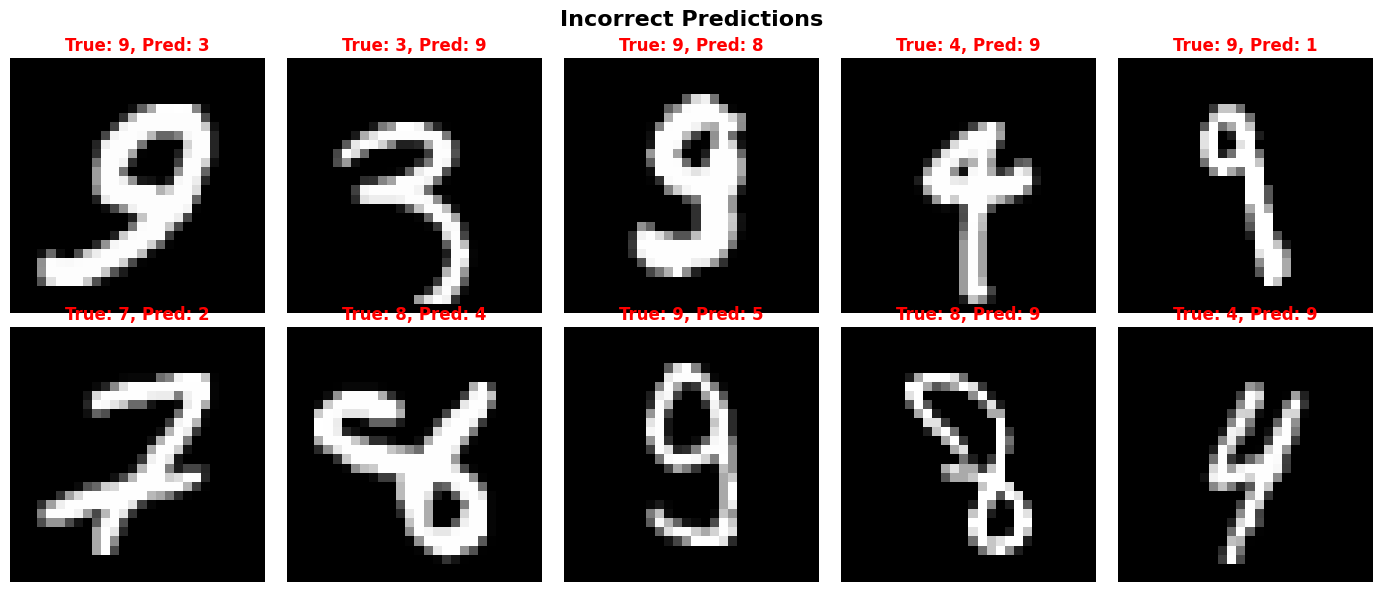

In [12]:
# Show some incorrect predictions
incorrect_mask = test_predictions != y_test
incorrect_indices = np.where(incorrect_mask)[0]

if len(incorrect_indices) >= 10:
    sample_incorrect = np.random.choice(incorrect_indices, size=10, replace=False)
    
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    for i, ax in enumerate(axes.flat):
        idx = sample_incorrect[i]
        img = X_test[idx].reshape(28, 28)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"True: {y_test[idx]}, Pred: {test_predictions[idx]}", 
                     color='red', fontweight='bold')
        ax.axis('off')
    plt.suptitle('Incorrect Predictions', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"Only {len(incorrect_indices)} incorrect predictions - model is very accurate!")

## Summary

This notebook demonstrated:
1. ✅ Loading and preprocessing MNIST dataset
2. ✅ Building a 3-layer neural network with myNN framework
3. ✅ Training with mini-batch gradient descent
4. ✅ Evaluating model performance
5. ✅ Visualizing results and predictions

The custom myNN framework successfully trained a neural network on MNIST!